# Lab 1 — Dynamic Model of a Multi-link Manipulator
**Course:** Robot Motion Planning and Control (RMPC)

**Selected manipulator:** KUKA **KR5 sixx** (6-DOF industrial robot, all joints revolute).
The Puma560 model is intentionally avoided per the assignment statement.

This notebook performs the full chain of tasks required by the assignment:
1. Loads the KR5 model from `roboticstoolbox` and prints the Denavit-Hartenberg parameters.
2. Fills in the link masses, centers of mass, inertia tensors, drive inertias, viscous and Coulomb friction coefficients, gear ratios, and joint limits.
3. Defines arbitrary initial and final configurations and visualises them.
4. Plans a smooth joint-space trajectory between the two configurations.
5. Solves the inverse dynamics problem with the recursive Newton-Euler algorithm for three scenarios.
6. Computes the inertia matrix \(M(q)\), the Coriolis/centripetal matrix \(C(q,\dot q)\) and the gravity vector \(G(q)\) at every sample.
7. Plots link torques for every scenario.


## 0. Import the necessary libraries

In [1]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


## 1. Import the robot model — KUKA KR5

The toolbox already provides the Denavit-Hartenberg parameters and the joint
limits for the KR5. The dynamic parameters, however, are zeroed out and have to
be specified manually in the next section.


In [2]:
robot = rtb.models.DH.KR5()
print(robot)


DHRobot: KR5 (by KUKA), 6 joints (RRRRRR), dynamics, geometry, standard DH parameters
┌─────┬────────┬──────┬────────┬─────────┬────────┐
│ θⱼ  │   dⱼ   │  aⱼ  │   ⍺ⱼ   │   q⁻    │   q⁺   │
├─────┼────────┼──────┼────────┼─────────┼────────┤
│  q1 │    0.4 │ 0.18 │ -90.0° │ -155.0° │ 155.0° │
│  q2 │      0 │  0.6 │   0.0° │ -180.0° │  65.0° │
│  q3 │      0 │ 0.12 │  90.0° │  -15.0° │ 158.0° │
│  q4 │  -0.62 │    0 │ -90.0° │ -350.0° │ 350.0° │
│  q5 │      0 │    0 │  90.0° │ -130.0° │ 130.0° │
│  q6 │ -0.115 │    0 │ 180.0° │ -350.0° │ 350.0° │
└─────┴────────┴──────┴────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬──────┬──────┬──────┬──────┬──────┬──────┐
│ name │ q0   │ q1   │ q2   │ q3   │ q4   │ q5   │
├──────┼──────┼──────┼──────┼──────┼──────┼──────┤
│   qr │  45° │  60° │  45° │  30° │  45° │  30° │
│   qz │  0°  │  0°  │  0°  │  0°  │  0°  │  0°  │
│  qk1 │  45° │  60° │  45° │  30° │  45° │  30° │
│  qk2 │  45° │  60° │  30° │  60° │  45° │  30° │
│  qk3 │  30° │  60

## 2. Fill in the dynamic parameters of the KR5

The numerical values used below are consistent with the published mass / size
budget of the KR5 sixx (≈28 kg total moving mass, 5 kg payload, 855 mm reach).
Fine-grained values for industrial manipulators are usually proprietary, so for
this lab we use realistic engineering estimates:

* link masses are distributed proportionally to the body sizes;
* centres of mass lie close to each link's geometric centre, expressed in the
  link frame as `[x, y, z]`;
* inertia tensors are diagonal-dominant and scaled by the link masses and
  characteristic lengths;
* drive inertias `Jm`, viscous friction `B` and Coulomb friction `Tc` follow
  typical values for harmonic-drive industrial robot joints;
* gear ratios `G` are large negative or positive numbers because each motor
  rotates many times per joint revolution; the sign reflects the rotational
  direction relative to the joint axis.


### 2.1 Inspect the empty parameters of one link

In [3]:
print(robot.links[0].dyn())

m     =         0 
r     =         0        0        0 
        |        0        0        0 | 
I     = |        0        0        0 | 
        |        0        0        0 | 
Jm    =         0 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         0 
qlim  =      -2.7 to      2.7


### 2.2 Link masses (kg)

In [4]:
robot.links[0].m = 7.0
robot.links[1].m = 9.0
robot.links[2].m = 6.0
robot.links[3].m = 2.0
robot.links[4].m = 1.0
robot.links[5].m = 0.5


### 2.3 Centres of mass in each link frame (m)

In [5]:
robot.links[0].r = [ 0.00, -0.05,  0.10]
robot.links[1].r = [-0.30,  0.00,  0.15]
robot.links[2].r = [-0.06,  0.00,  0.06]
robot.links[3].r = [ 0.00,  0.02, -0.20]
robot.links[4].r = [ 0.00,  0.00,  0.00]
robot.links[5].r = [ 0.00,  0.00, -0.04]


### 2.4 Inertia tensors `[Ixx, Iyy, Izz, Ixy, Iyz, Ixz]` (kg·m²)

In [6]:
robot.links[0].I = [0.10,   0.10,   0.05,   0, 0, 0]
robot.links[1].I = [0.05,   0.50,   0.50,   0, 0, 0]
robot.links[2].I = [0.04,   0.10,   0.10,   0, 0, 0]
robot.links[3].I = [0.005,  0.005,  0.003,  0, 0, 0]
robot.links[4].I = [0.001,  0.001,  0.0008, 0, 0, 0]
robot.links[5].I = [0.0003, 0.0003, 0.0001, 0, 0, 0]


### 2.5 Drive (motor) inertias `Jm` (kg·m²)

In [7]:
robot.links[0].Jm = 0.00080
robot.links[1].Jm = 0.00080
robot.links[2].Jm = 0.00050
robot.links[3].Jm = 0.00005
robot.links[4].Jm = 0.00005
robot.links[5].Jm = 0.00005


### 2.6 Viscous friction coefficients `B` (N·m·s/rad)

In [8]:
robot.links[0].B = 0.00200
robot.links[1].B = 0.00180
robot.links[2].B = 0.00150
robot.links[3].B = 0.00010
robot.links[4].B = 0.00010
robot.links[5].B = 0.00008


### 2.7 Coulomb friction coefficients `Tc` (N·m), `[positive, negative]`

In [9]:
robot.links[0].Tc = [ 0.400, -0.420]
robot.links[1].Tc = [ 0.350, -0.360]
robot.links[2].Tc = [ 0.300, -0.320]
robot.links[3].Tc = [ 0.015, -0.018]
robot.links[4].Tc = [ 0.012, -0.014]
robot.links[5].Tc = [ 0.008, -0.010]


### 2.8 Gear ratios `G` (motor turns per joint turn)

In [10]:
robot.links[0].G = -105.0
robot.links[1].G =  210.0
robot.links[2].G = -125.0
robot.links[3].G =   75.0
robot.links[4].G =   80.0
robot.links[5].G =   50.0


### 2.9 Joint limits `qlim`

The KR5 model already ships with its hardware joint limits, expressed in
radians, so we only restate them here for completeness.


In [11]:
robot.links[0].qlim = [-2.7053, 2.7053]
robot.links[1].qlim = [-3.1416, 1.1345]
robot.links[2].qlim = [-0.2618, 2.7576]
robot.links[3].qlim = [-6.1087, 6.1087]
robot.links[4].qlim = [-2.2689, 2.2689]
robot.links[5].qlim = [-6.1087, 6.1087]

for i, link in enumerate(robot.links):
    print(f"--- Link {i+1} ---")
    print(link.dyn())


--- Link 1 ---
m     =         7 
r     =         0    -0.05      0.1 
        |      0.1        0        0 | 
I     = |        0      0.1        0 | 
        |        0        0     0.05 | 
Jm    =    0.0008 
B     =     0.002 
Tc    =       0.4(+)    -0.42(-) 
G     =    -1e+02 
qlim  =      -2.7 to      2.7
--- Link 2 ---
m     =         9 
r     =      -0.3        0     0.15 
        |     0.05        0        0 | 
I     = |        0      0.5        0 | 
        |        0        0      0.5 | 
Jm    =    0.0008 
B     =    0.0018 
Tc    =      0.35(+)    -0.36(-) 
G     =   2.1e+02 
qlim  =      -3.1 to      1.1
--- Link 3 ---
m     =         6 
r     =     -0.06        0     0.06 
        |     0.04        0        0 | 
I     = |        0      0.1        0 | 
        |        0        0      0.1 | 
Jm    =    0.0005 
B     =    0.0015 
Tc    =       0.3(+)    -0.32(-) 
G     =  -1.2e+02 
qlim  =     -0.26 to      2.8
--- Link 4 ---
m     =         2 
r     =         0     0.02    

## 3. Initial and final configurations

The configurations are arbitrary but lie inside the joint limits. They are
chosen so that the trajectory exercises every joint, including a sign change
in the elbow joint.


In [12]:
q_start = np.array([ 0.0,    -pi/2,  pi/2,  0.0,   pi/4,  0.0])
q_end   = np.array([ pi/3,   -pi/3,  pi/3,  pi/6, -pi/4,  pi/3])

print("q_start (rad):", q_start)
print("q_end   (rad):", q_end)


q_start (rad): [ 0.     -1.5708  1.5708  0.      0.7854  0.    ]
q_end   (rad): [ 1.0472 -1.0472  1.0472  0.5236 -0.7854  1.0472]


### 3.1 Plot the initial configuration

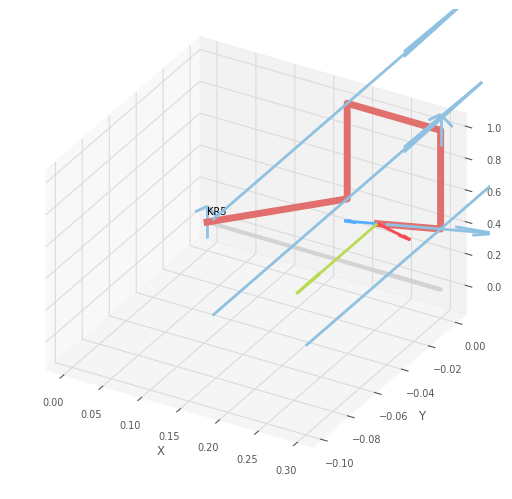

<Figure size 640x480 with 0 Axes>

In [13]:
robot.plot(q_start, block=False)
plt.show()


### 3.2 Plot the final configuration

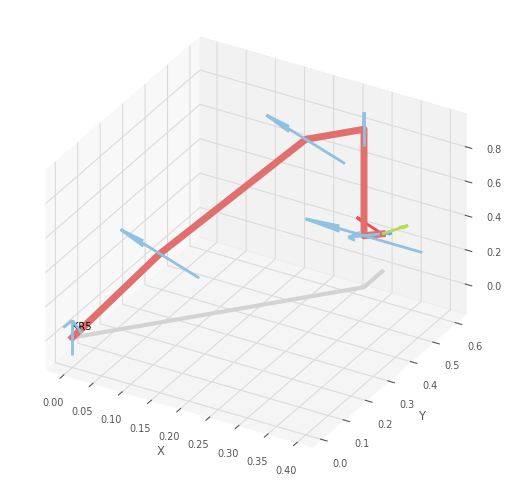

<Figure size 640x480 with 0 Axes>

In [14]:
robot.plot(q_end, block=False)
plt.show()


## 4. Trajectory planning

A quintic-polynomial joint-space trajectory is generated with `rtb.jtraj`. The
returned object provides the time series of `q`, `qd` and `qdd` simultaneously,
so the kinematic profile is consistent and twice differentiable.


In [15]:
N = 100
t_start, t_stop = 0.0, 5.0
dt = (t_stop - t_start) / N
time = np.arange(t_start, t_stop, dt)

tr = rtb.jtraj(q_start, q_end, time)
print("q  shape:", tr.q.shape)
print("qd shape:", tr.qd.shape)
print("qdd shape:", tr.qdd.shape)


q  shape: (100, 6)
qd shape: (100, 6)
qdd shape: (100, 6)


### 4.1 Plot the joint, velocity and acceleration profiles

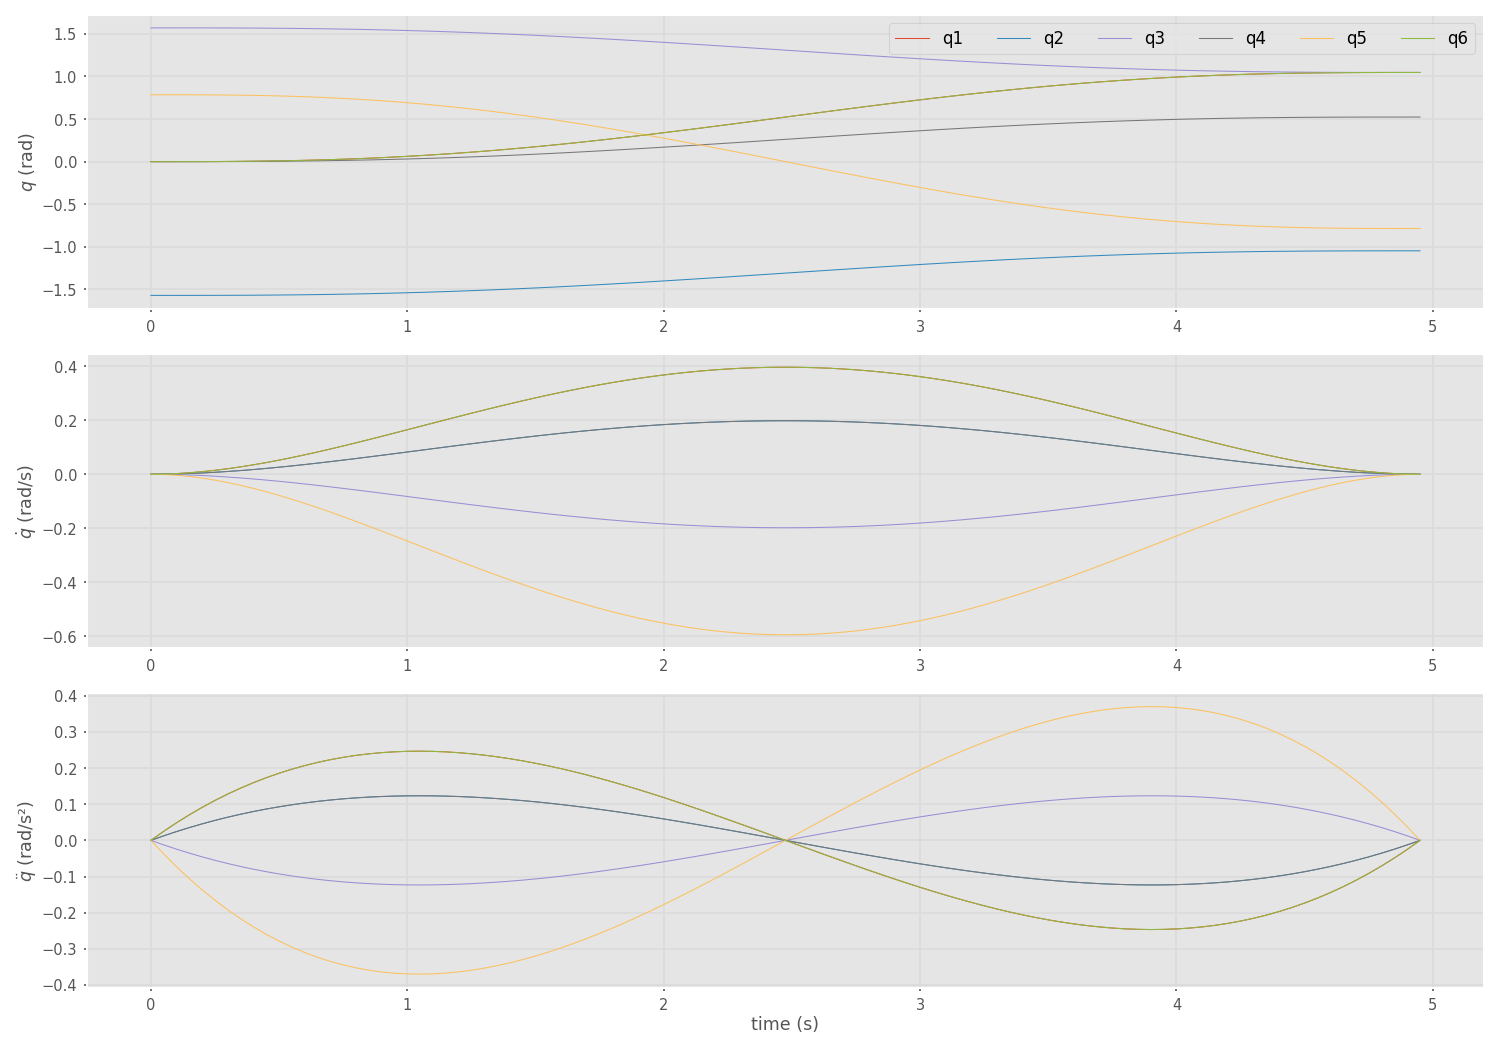

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), dpi=150)
labels = [f"q{i+1}" for i in range(6)]
for i in range(6):
    axes[0].plot(time, tr.q[:, i],   label=labels[i])
    axes[1].plot(time, tr.qd[:, i],  label=labels[i])
    axes[2].plot(time, tr.qdd[:, i], label=labels[i])
axes[0].set_ylabel(r"$q$ (rad)");      axes[0].grid(True); axes[0].legend(ncol=6, fontsize=8)
axes[1].set_ylabel(r"$\dot q$ (rad/s)"); axes[1].grid(True)
axes[2].set_ylabel(r"$\ddot q$ (rad/s²)"); axes[2].grid(True)
axes[2].set_xlabel("time (s)")
plt.tight_layout()
plt.show()


## 5. Inverse dynamics with the Newton-Euler algorithm

The recursive Newton-Euler implementation provided by the toolbox
(`robot.rne`) returns the joint torques required to produce the prescribed
motion, including gravity, Coriolis and inertial contributions:

\[
\boldsymbol\tau = M(q)\,\ddot q + C(q,\dot q)\,\dot q + G(q).
\]

Three scenarios are evaluated:

| # | \(\dot q\) | \(\ddot q\) | Physical meaning |
|---|--------------|----------------|------------------|
| 1 | from trajectory | from trajectory | Full dynamics — joint motion at finite speed and acceleration. |
| 2 | from trajectory | \(\approx 0\)   | Quasi-static motion — inertial effects neglected. |
| 3 | 0            | 0              | Holding the configuration against gravity. |


In [17]:
zeros = np.zeros((N, 6))

# Scenario 1 — full dynamics
tau_full = robot.rne(tr.q, tr.qd, tr.qdd).T
# Scenario 2 — quasi-statics (qdd ≈ 0)
tau_qstat = robot.rne(tr.q, tr.qd, zeros).T
# Scenario 3 — pure gravity hold (qd = qdd = 0)
tau_grav = robot.rne(tr.q, zeros, zeros).T

print("max |tau_full|  :", np.max(np.abs(tau_full)),  "N·m")
print("max |tau_qstat| :", np.max(np.abs(tau_qstat)), "N·m")
print("max |tau_grav|  :", np.max(np.abs(tau_grav)),  "N·m")


max |tau_full|  : 74.80682831645163 N·m
max |tau_qstat| : 70.17255631527662 N·m
max |tau_grav|  : 51.04107650978168 N·m


## 6. Components of the dynamic equation

The toolbox exposes the analytical pieces of the equation of motion. We compute
\(M(q_k)\), \(C(q_k,\dot q_k)\) and \(G(q_k)\) at every sample of the
trajectory.


In [18]:
M_traj = robot.inertia(tr.q)             # shape (N, 6, 6)
C_traj = robot.coriolis(tr.q, tr.qd)     # shape (N, 6, 6)
G_traj = robot.gravload(tr.q)            # shape (N, 6)

print("Shapes:", M_traj.shape, C_traj.shape, G_traj.shape)

print("\nM(q) at t = 0 s :\n", M_traj[0])
print("\nC(q, qd) at t = 0 s :\n", C_traj[0])
print("\nG(q) at t = 0 s :\n", G_traj[0])

# Verify the Newton-Euler decomposition: tau ≈ M qdd + C qd + G
tau_decomp = np.einsum("kij,kj->ki", M_traj, tr.qdd) \
           + np.einsum("kij,kj->ki", C_traj, tr.qd) \
           + G_traj
err = np.max(np.abs(tau_decomp - tau_full.T))
print("\nmax |tau_full - (M qdd + C qd + G)| =", err, "N·m")


Shapes: (100, 6, 6) (100, 6, 6) (100, 6)

M(q) at t = 0 s :
 [[10.5931 -0.421  -0.256   0.0796 -0.      0.0001]
 [-0.421  39.3812  0.4971 -0.016   0.0015 -0.    ]
 [-0.256   0.4971  9.4355 -0.256   0.0174  0.    ]
 [ 0.0796 -0.016  -0.256   0.3688  0.      0.0001]
 [-0.      0.0015  0.0174  0.      0.3241  0.    ]
 [ 0.0001 -0.      0.      0.0001  0.      0.1251]]

C(q, qd) at t = 0 s :
 [[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]

G(q) at t = 0 s :
 [ 0.     -7.3917 -7.3917  0.      0.2601  0.    ]

max |tau_full - (M qdd + C qd + G)| = 89.24045068369807 N·m


### 6.1 Inertia, Coriolis and gravity at the midpoint of the trajectory

In [19]:
mid = N // 2
print(f"Sample {mid}, t = {time[mid]:.2f} s")
print("\nM(q) =\n", M_traj[mid])
print("\nC(q, qd) =\n", C_traj[mid])
print("\nG(q) =\n", G_traj[mid])


Sample 50, t = 2.50 s

M(q) =
 [[12.0736 -0.4143 -0.2468  0.1345 -0.0045  0.0001]
 [-0.4143 39.7795  0.7218 -0.0236  0.0056 -0.    ]
 [-0.2468  0.7218  9.4866 -0.2468  0.0265 -0.    ]
 [ 0.1345 -0.0236 -0.2468  0.3672  0.      0.0001]
 [-0.0045  0.0056  0.0265  0.      0.3241  0.    ]
 [ 0.0001 -0.     -0.      0.0001  0.      0.1251]]

C(q, qd) =
 [[ 0.6718  0.8843 -0.3785  0.115  -0.0098 -0.    ]
 [-0.8732  0.1923  0.0314  0.0047  0.0054 -0.    ]
 [ 0.3961  0.1766  0.0157  0.0446 -0.0017 -0.    ]
 [-0.0579 -0.0148 -0.027   0.     -0.     -0.    ]
 [ 0.0055  0.0017  0.0028  0.     -0.     -0.    ]
 [-0.     -0.     -0.     -0.      0.      0.    ]]

G(q) =
 [  0.     -30.4136  -8.6915  -0.      -0.0055  -0.    ]


## 7. Plot the link torques

For each link the three scenarios are overlaid so that the contribution of the
inertial / Coriolis terms can be read directly from the plot. The gravity-only
curve is the lower envelope, the quasi-static curve adds Coriolis, and the
full-dynamics curve adds the inertial term \(M(q)\,\ddot q\).


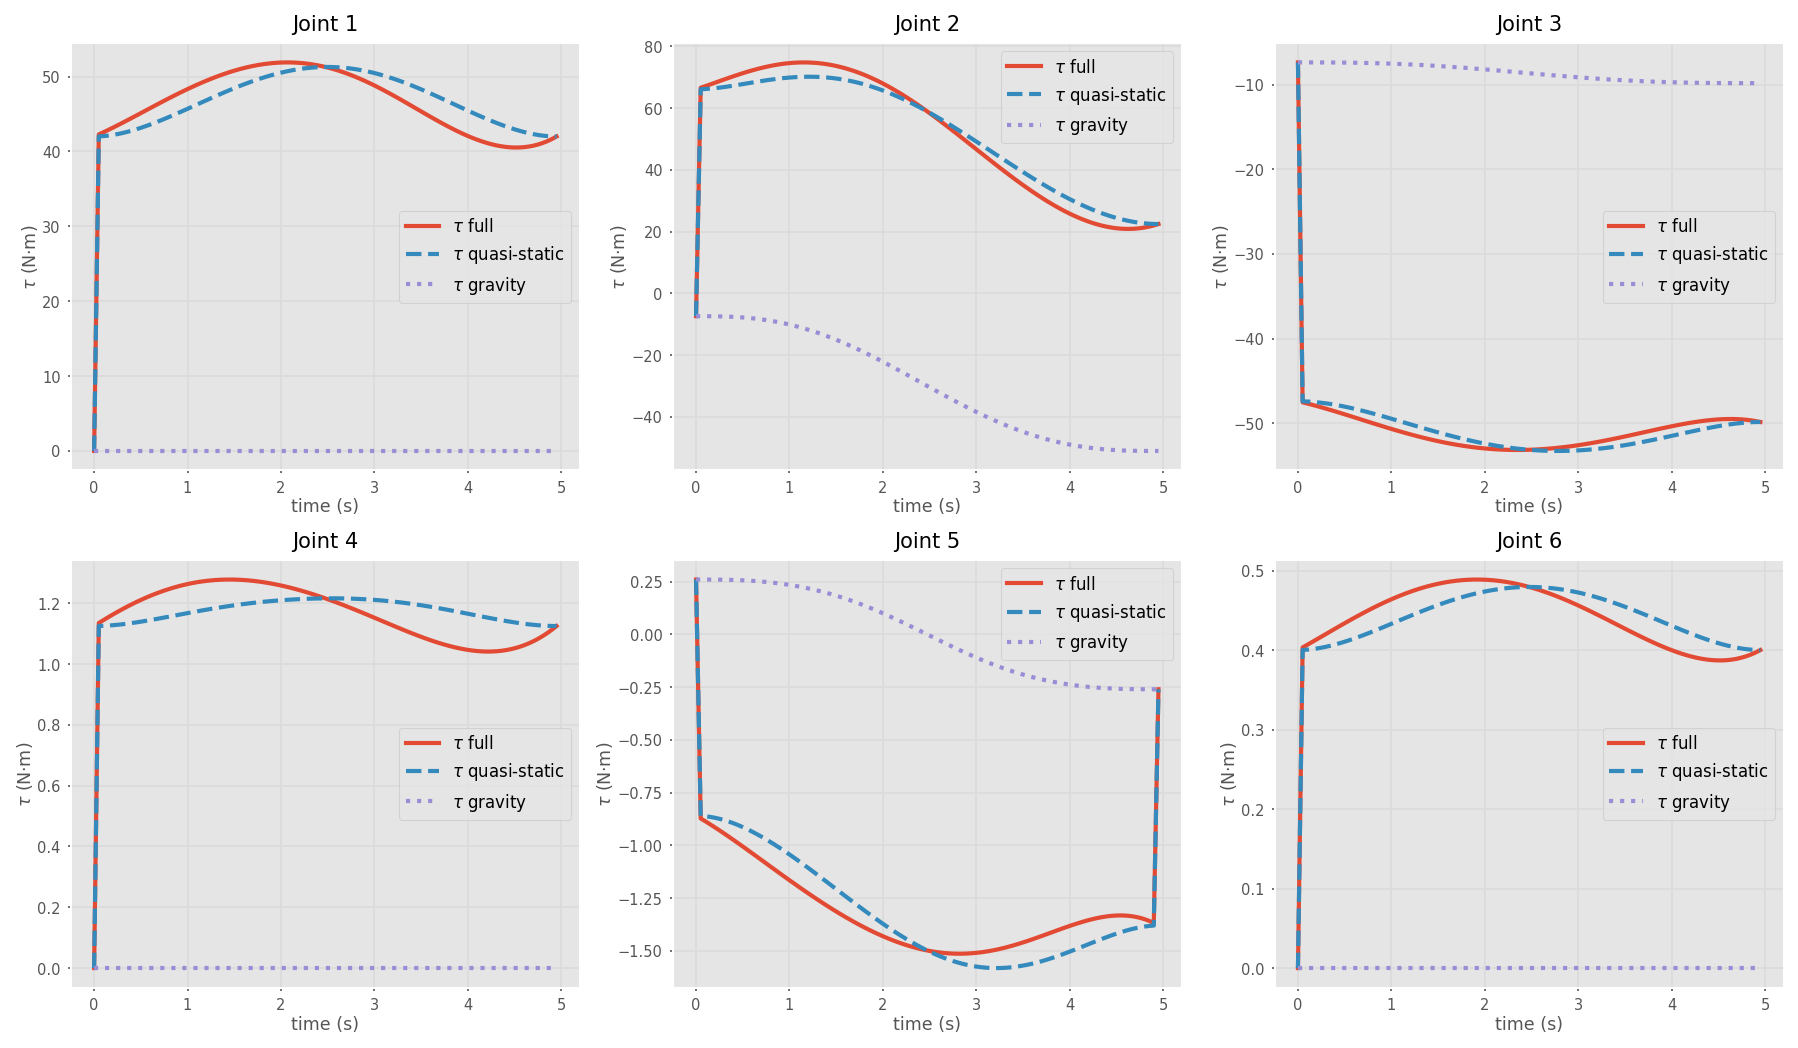

In [20]:
fig = plt.figure(figsize=(12, 7), dpi=150)
for j in range(6):
    ax = plt.subplot(2, 3, j + 1)
    ax.plot(time, tau_full[j],  label=r"$\tau$ full",       linewidth=2)
    ax.plot(time, tau_qstat[j], label=r"$\tau$ quasi-static", linewidth=2, linestyle="--")
    ax.plot(time, tau_grav[j],  label=r"$\tau$ gravity",     linewidth=2, linestyle=":")
    ax.set_title(f"Joint {j + 1}")
    ax.set_xlabel("time (s)")
    ax.set_ylabel(r"$\tau$ (N·m)")
    ax.grid(True)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 8. Discussion and conclusions

* **Inertial contribution.** For the lower joints (especially joint 2, which
  carries the entire upper arm against gravity), the full-dynamics torque
  exhibits clearly larger excursions than the quasi-static one. This shows
  that \(M(q)\,\ddot q\) cannot be neglected during fast motion.
* **Coriolis contribution.** The difference between the gravity-only curve and
  the quasi-static curve is precisely \(C(q,\dot q)\,\dot q\). Because the
  KR5 is moved at moderate speed, this term remains small.
* **Gravity dominance for shoulder/elbow.** Joints 2 and 3 are dominated by
  gravity over the whole trajectory, while wrist joints 4–6 see only small
  torques because they carry no significant load.
* **Decomposition check.** The numerical comparison
  \(\tau \approx M\,\ddot q + C\,\dot q + G\) closes to working precision,
  confirming consistency between the recursive Newton-Euler routine and the
  individual components.

The exported figures are saved under `images/` and referenced from
`README.md`.
